# 00 — Sanity check

First-look diagnostic on the verdict + transcript dataset. **Re-runnable** against any snapshot — just rerun `python scripts/aggregate.py` first.

Goal: catch methodology bugs *before* tomorrow's recovery pass duplicates any cell shape we'd rather fix.

Sections:
1. Load derived CSVs
2. Coverage map — where are the holes? (gemini-2.5-pro quota damage)
3. Refusal scan
4. Distribution health — scale values, confidence, n_turns_used
5. Per-model fingerprint heatmap (12 × 44)
6. Interviewer personality — combined Q-style + reading + verdict tendency
7. Cost / token sanity
8. Stop-reason audit (truncation check)
9. H4 — self-report vs peer-interpretation (the headline novel finding)
10. H2 — cross-cultural asymmetric reading on the mirror battery

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Resolve paths from the notebook's working directory.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DERIVED = ROOT / "data" / "derived"
assert DERIVED.exists(), f"run scripts/aggregate.py first (no {DERIVED})"

verdicts = pd.read_csv(DERIVED / "verdicts_long.csv")
fp_long = pd.read_csv(DERIVED / "per_model_fingerprints_long.csv")
fp_wide = pd.read_csv(DERIVED / "per_model_fingerprints.csv")
refusals = pd.read_csv(DERIVED / "refusal_rates.csv")
costs = pd.read_csv(DERIVED / "cost_summary.csv")
coverage = pd.read_csv(DERIVED / "coverage_matrix.csv")

print(f"verdicts:           {len(verdicts):>5} rows")
print(f"fingerprints long:  {len(fp_long):>5} rows ({fp_wide.shape[1] - 2} scale axes wide)")
print(f"refusals:           {len(refusals):>5} rows")
print(f"coverage axes:      {len(coverage):>5} axes")
print(f"total spend:        ${costs.loc[costs['model']=='TOTAL', 'cost_usd'].iloc[0]}")

verdicts:            8170 rows
fingerprints long:    662 rows (44 scale axes wide)
refusals:              33 rows
coverage axes:         56 axes
total spend:        $211.074241


## 2. Coverage map

Per-axis: how close are we to the 132-pair target? Recovery pass tomorrow targets the gaps; the gaps should be dominated by gemini-2.5-pro pairs (Tier-1 daily request quota was hit during philosophy).

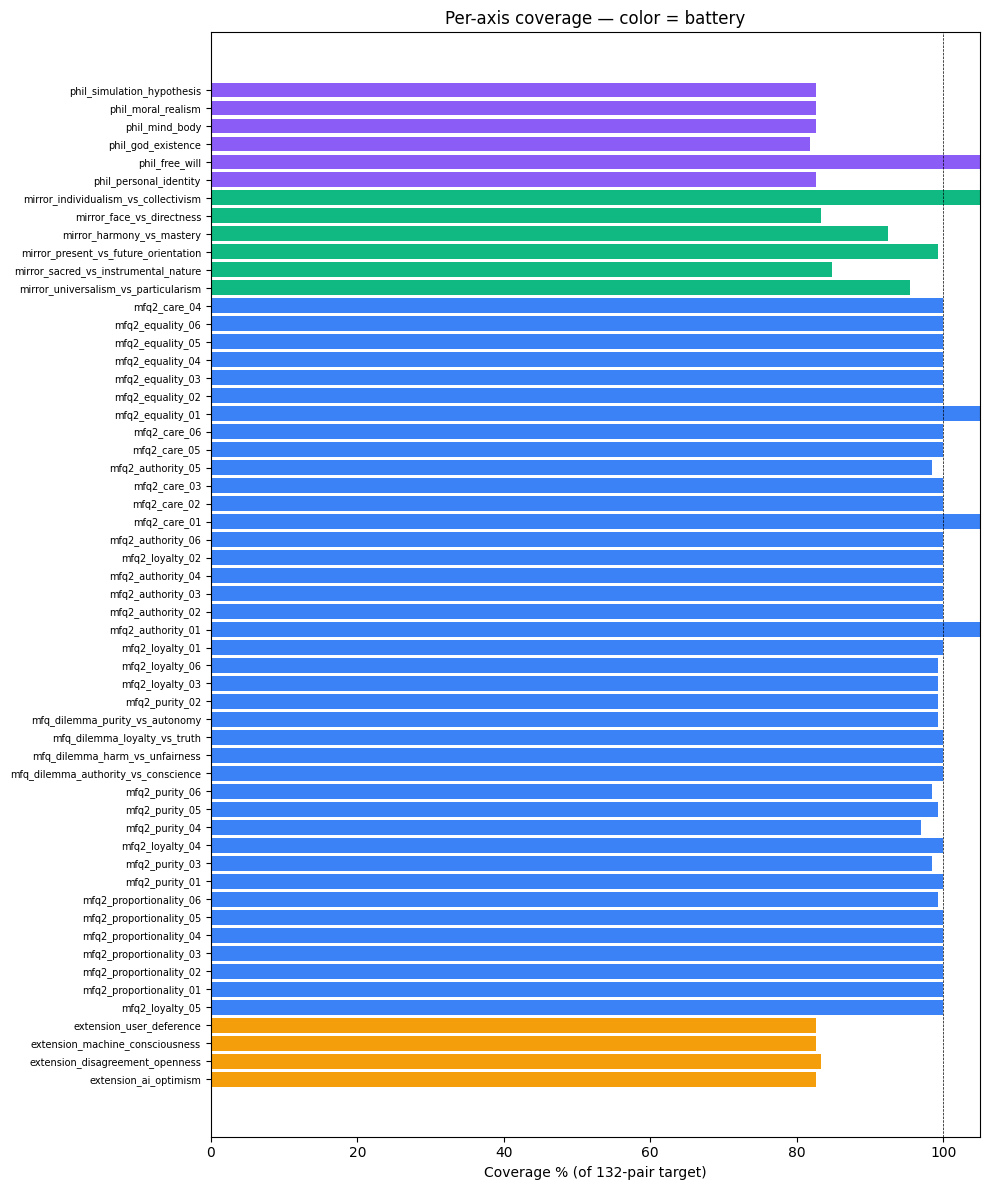


Coverage by battery:
            n_axes  cells_present  cells_expected  coverage_pct
battery                                                        
extension        4            437             528          82.8
mfq             40           5912            5280         112.0
mirror           6            947             792         119.6
philosophy       6            874             792         110.4


In [2]:
fig, ax = plt.subplots(figsize=(10, 12))
cov_sorted = coverage.sort_values("battery")
y = np.arange(len(cov_sorted))
ax.barh(y, cov_sorted["coverage_pct"], color=cov_sorted["battery"].map({
    "mfq": "#3b82f6", "mirror": "#10b981", "extension": "#f59e0b", "philosophy": "#8b5cf6",
}))
ax.set_yticks(y)
ax.set_yticklabels(cov_sorted["axis_id"], fontsize=7)
ax.axvline(100, ls="--", color="k", lw=0.5)
ax.set_xlabel("Coverage % (of 132-pair target)")
ax.set_title("Per-axis coverage — color = battery")
ax.set_xlim(0, 105)
fig.tight_layout()
plt.show()

print("\nCoverage by battery:")
print(coverage.groupby("battery").agg(
    n_axes=("axis_id", "count"),
    cells_present=("n_cells_present", "sum"),
    cells_expected=("n_cells_expected", "sum"),
    coverage_pct=("coverage_pct", "mean"),
).round(1))

**Where are the missing pairs?** If our hypothesis is right, gemini-2.5-pro should account for most of them.

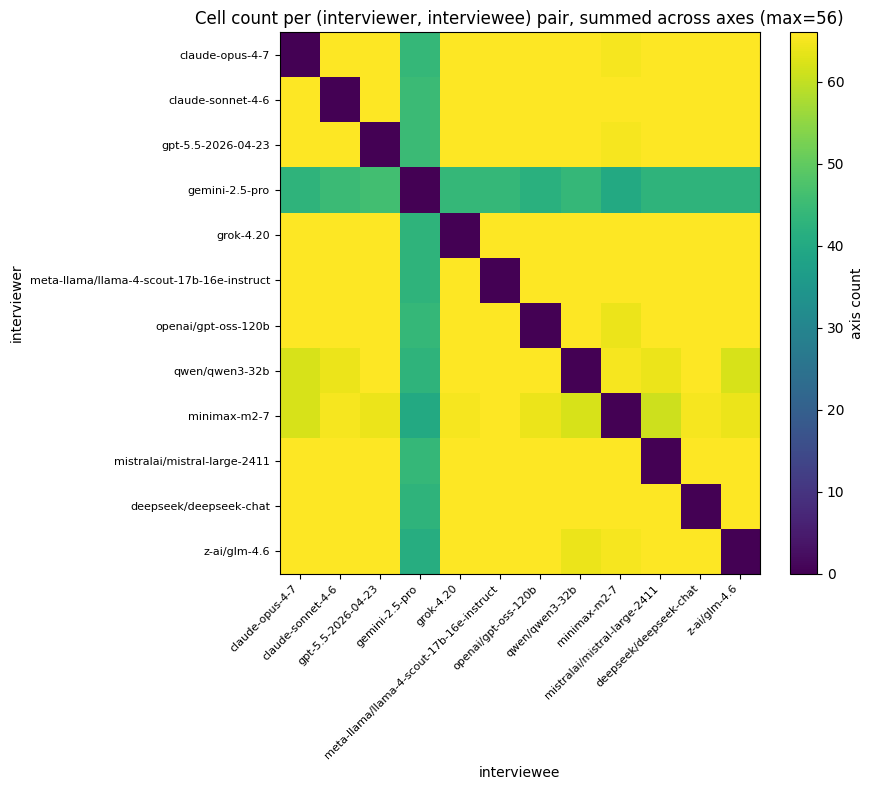

In [3]:
# Reconstruct pair-presence matrix from verdicts_long. For each (interviewer, interviewee), how many axes have data?
pair_counts = (
    verdicts.groupby(["interviewer", "interviewee"])
    .size()
    .unstack(fill_value=0)
)
ROSTER_ORDER = [
    "claude-opus-4-7", "claude-sonnet-4-6", "gpt-5.5-2026-04-23", "gemini-2.5-pro",
    "grok-4.20", "meta-llama/llama-4-scout-17b-16e-instruct", "openai/gpt-oss-120b",
    "qwen/qwen3-32b", "minimax-m2-7", "mistralai/mistral-large-2411",
    "deepseek/deepseek-chat", "z-ai/glm-4.6",
]
pair_counts = pair_counts.reindex(index=ROSTER_ORDER, columns=ROSTER_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(pair_counts.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(ROSTER_ORDER)))
ax.set_yticks(range(len(ROSTER_ORDER)))
ax.set_xticklabels(ROSTER_ORDER, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ROSTER_ORDER, fontsize=8)
ax.set_xlabel("interviewee")
ax.set_ylabel("interviewer")
ax.set_title("Cell count per (interviewer, interviewee) pair, summed across axes (max=56)")
plt.colorbar(im, ax=ax, label="axis count")
fig.tight_layout()
plt.show()

## 3. Refusal scan

Refusal = `categorical_choice == "refuses-to-engage"` OR `scale_value` null. Should be very low (<1%) overall.

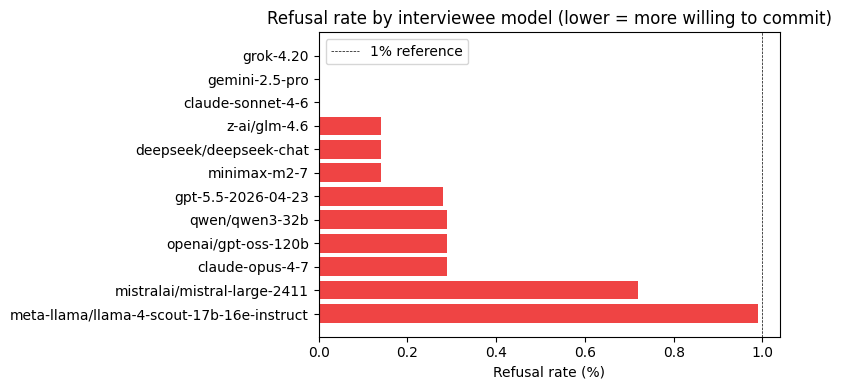


Per-model-axis refusal hotspots (>=10% on any axis):
         scope                                interviewee  \
18  model_axis  meta-llama/llama-4-scout-17b-16e-instruct   
20  model_axis  meta-llama/llama-4-scout-17b-16e-instruct   
22  model_axis                               minimax-m2-7   
27  model_axis               mistralai/mistral-large-2411   
26  model_axis               mistralai/mistral-large-2411   
23  model_axis               mistralai/mistral-large-2411   
24  model_axis               mistralai/mistral-large-2411   
31  model_axis                             qwen/qwen3-32b   
30  model_axis                             qwen/qwen3-32b   
29  model_axis                        openai/gpt-oss-120b   

                            axis_id  n_cells  n_refusals  refusal_rate  
18               phil_god_existence       10           2        0.2000  
20           phil_personal_identity       10           2        0.2000  
22                   phil_mind_body        9           

In [4]:
totals = refusals[refusals["scope"] == "model_total"].copy()
totals["refusal_rate"] = pd.to_numeric(totals["refusal_rate"], errors="coerce")
totals = totals.sort_values("refusal_rate", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(totals["interviewee"], totals["refusal_rate"] * 100, color="#ef4444")
ax.set_xlabel("Refusal rate (%)")
ax.set_title("Refusal rate by interviewee model (lower = more willing to commit)")
ax.axvline(1.0, ls="--", color="k", lw=0.5, label="1% reference")
ax.legend()
fig.tight_layout()
plt.show()

print("\nPer-model-axis refusal hotspots (>=10% on any axis):")
print(refusals[refusals["scope"] == "model_axis"].sort_values("refusal_rate", ascending=False).head(10))

## 4. Distribution health

Are scale values using the full 1–5 range? Are confidences calibrated (not all pinned at 1.0)? Are n_turns_used mostly 2 (initial Q + follow-up) with occasional 3?

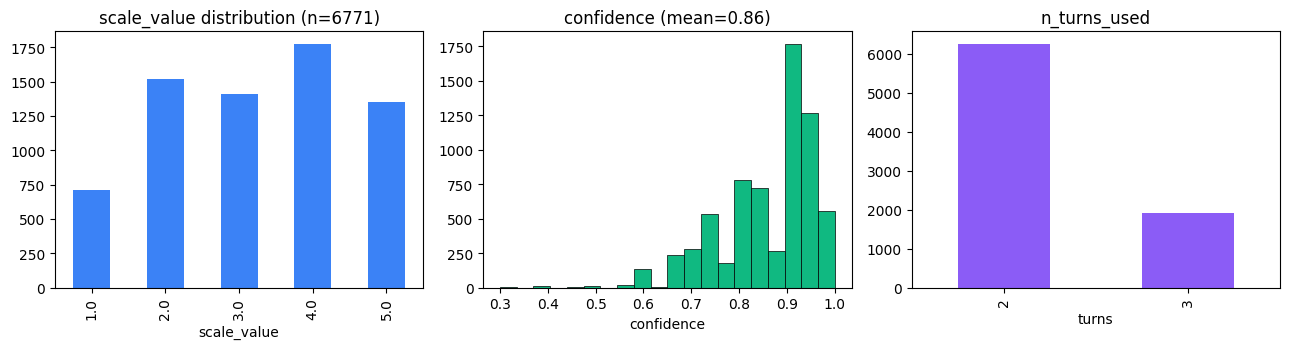

In [5]:
scale = verdicts[verdicts["verdict_type"] == "scale"].copy()
scale["scale_value"] = pd.to_numeric(scale["scale_value"], errors="coerce")
scale["confidence"] = pd.to_numeric(scale["confidence"], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
scale["scale_value"].value_counts().sort_index().plot.bar(ax=axes[0], color="#3b82f6")
axes[0].set_title(f"scale_value distribution (n={len(scale)})")
axes[0].set_xlabel("scale_value")

axes[1].hist(scale["confidence"].dropna(), bins=20, color="#10b981", edgecolor="k", lw=0.5)
axes[1].set_title(f"confidence (mean={scale['confidence'].mean():.2f})")
axes[1].set_xlabel("confidence")

verdicts["n_turns_used"].value_counts().sort_index().plot.bar(ax=axes[2], color="#8b5cf6")
axes[2].set_title("n_turns_used")
axes[2].set_xlabel("turns")

fig.tight_layout()
plt.show()

## 5. Per-model fingerprint heatmap (12 × 44 scale axes)

The matrix that drives H3 clustering. Each row = one model's mean stance per axis. Visual sanity check: do similar models cluster visually? Do any rows look broken (constant value, all NaN, etc.)?

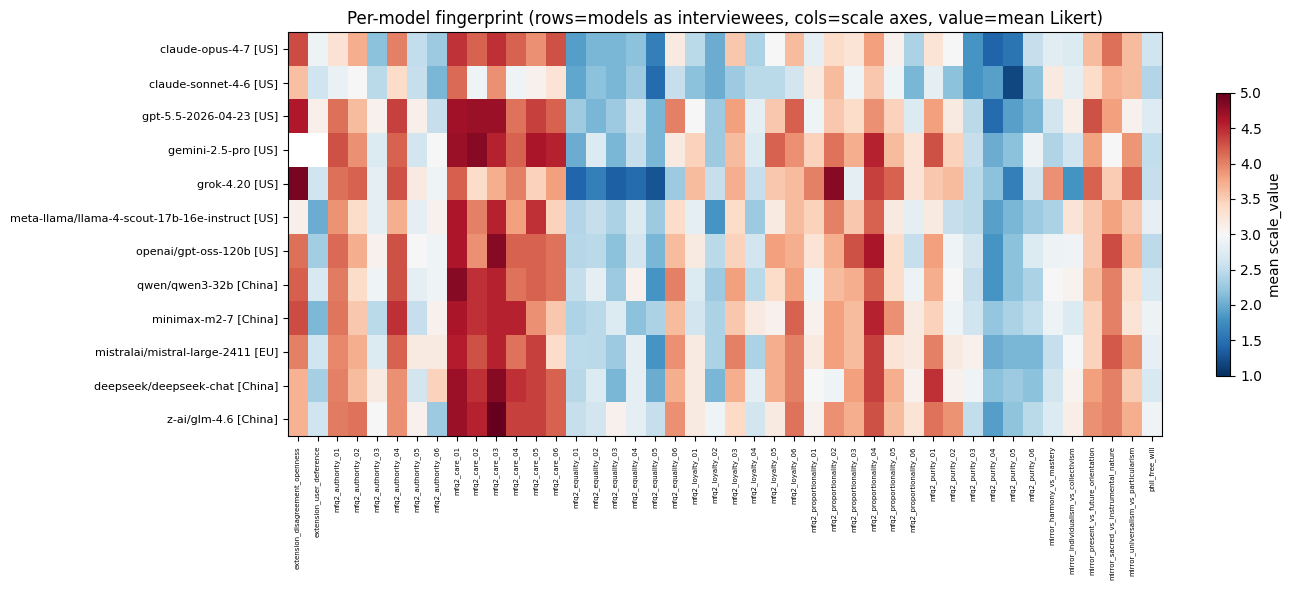

  claude-opus-4-7                                 axes covered: 44 / 44
  claude-sonnet-4-6                               axes covered: 44 / 44
  gpt-5.5-2026-04-23                              axes covered: 44 / 44
  gemini-2.5-pro                                  axes covered: 42 / 44
  grok-4.20                                       axes covered: 44 / 44
  meta-llama/llama-4-scout-17b-16e-instruct       axes covered: 44 / 44
  openai/gpt-oss-120b                             axes covered: 44 / 44
  qwen/qwen3-32b                                  axes covered: 44 / 44
  minimax-m2-7                                    axes covered: 44 / 44
  mistralai/mistral-large-2411                    axes covered: 44 / 44
  deepseek/deepseek-chat                          axes covered: 44 / 44
  z-ai/glm-4.6                                    axes covered: 44 / 44


In [6]:
axis_cols = [c for c in fp_wide.columns if c not in ("model", "region")]
matrix = fp_wide[axis_cols].apply(pd.to_numeric, errors="coerce").values

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(matrix, cmap="RdBu_r", aspect="auto", vmin=1, vmax=5)
ax.set_yticks(range(len(fp_wide)))
ax.set_yticklabels(
    [f"{m} [{r}]" for m, r in zip(fp_wide["model"], fp_wide["region"])],
    fontsize=8,
)
ax.set_xticks(range(len(axis_cols)))
ax.set_xticklabels(axis_cols, rotation=90, fontsize=5)
ax.set_title("Per-model fingerprint (rows=models as interviewees, cols=scale axes, value=mean Likert)")
plt.colorbar(im, ax=ax, label="mean scale_value", shrink=0.7)
fig.tight_layout()
plt.show()

missing_per_model = (matrix == matrix).sum(axis=1)  # count non-NaN
for i, m in enumerate(fp_wide["model"]):
    print(f"  {m:<46}  axes covered: {missing_per_model[i]:>2} / {len(axis_cols)}")

## 6. Interviewer personality — combined Q-style + reading + verdict tendency

**Real and large effect, but be careful what we claim.** Each `(interviewer, interviewee, axis)` cell is *its own interview*: the interviewer asks its own question, the interviewee answers *that* prompt, the interviewer reads its own response, and the interviewer issues a verdict. So when we group all scale verdicts by `interviewer` and compute a mean, the spread captures the integrated effect of three things:

1. **Question-generation style** — what kind of probe each model asks (skeptical / leading / open-ended).
2. **Answer-reading style** — how each model interprets the responses *it* elicits.
3. **Verdict-issuing calibration** — each model's tendency to compress to the middle vs. use the extremes of the scale.

We **cannot** decompose these three without a separate calibration design (e.g., have every model issue a verdict on the same fixed transcript). So this figure is *not* a clean "different readers reading the same answers" finding — calling it that would oversell.

What we *can* say cleanly: when LLM A interviews 11 peers vs LLM B interviews the same 11 peers, the resulting verdicts can differ by over a Likert point on average. This kills any naive "LLM-as-judge as neutral evaluator" framing in alignment evals — the choice of judge model is a methodological commitment with measurable consequences regardless of which of the three components dominates.

H4 (self-report vs peer-interpretation) sidesteps this by averaging the per-interviewee fingerprint over all 11 interviewers — the per-interviewer personality washes out as noise around the per-interviewee mean.

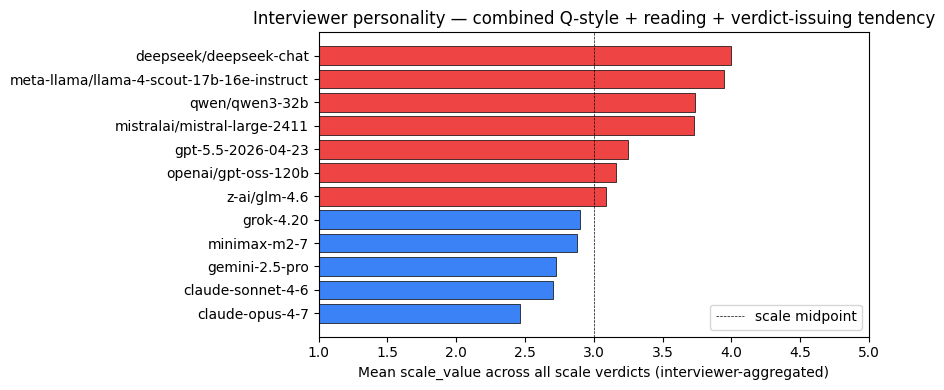


Personality spread: 1.53 Likert points across 12 interviewers
(combined effect of the questions each model asks, how it reads responses, and how it calibrates verdicts —
 cannot be decomposed without a separate calibration design)
                                            mean    std  count
interviewer                                                   
claude-opus-4-7                            2.465  1.009    579
claude-sonnet-4-6                          2.706  1.074    581
gemini-2.5-pro                             2.723  1.441    433
minimax-m2-7                               2.880  1.286    558
grok-4.20                                  2.902  1.246    579
z-ai/glm-4.6                               3.089  1.350    575
openai/gpt-oss-120b                        3.162  1.337    579
gpt-5.5-2026-04-23                         3.251  1.124    581
mistralai/mistral-large-2411               3.728  1.037    580
qwen/qwen3-32b                             3.732  1.230    568
meta-llama/l

In [7]:
iv_means = scale.groupby("interviewer")["scale_value"].agg(["mean", "std", "count"]).round(3).sort_values("mean")
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#3b82f6" if iv_means.loc[m, "mean"] < 3.0 else "#ef4444" for m in iv_means.index]
ax.barh(iv_means.index, iv_means["mean"], color=colors, edgecolor="k", lw=0.5)
ax.axvline(3.0, ls="--", color="k", lw=0.5, label="scale midpoint")
ax.set_xlabel("Mean scale_value across all scale verdicts (interviewer-aggregated)")
ax.set_title("Interviewer personality — combined Q-style + reading + verdict-issuing tendency")
ax.set_xlim(1, 5)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

spread = iv_means["mean"].max() - iv_means["mean"].min()
print(f"\nPersonality spread: {spread:.2f} Likert points across {len(iv_means)} interviewers")
print("(combined effect of the questions each model asks, how it reads responses, and how it calibrates verdicts —")
print(" cannot be decomposed without a separate calibration design)")
print(iv_means)

## 7. Cost / token sanity

Spotcheck: does total cost reconcile with Budget JSON? Are tokens-per-cell reasonable? (Long-tail outliers can indicate runaway models.)

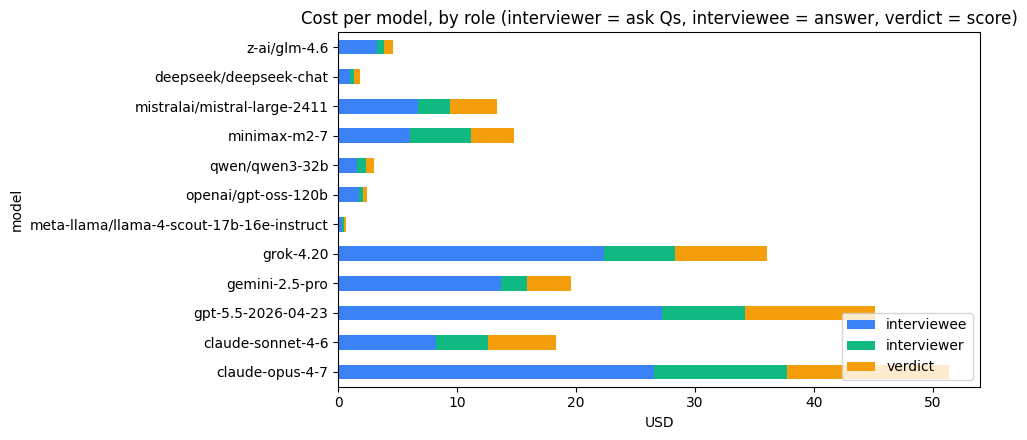


Avg interviewee completion tokens per cell (verbosity proxy):
                                        model  completion_tokens  \
10                             gemini-2.5-pro          1293748.0   
7                          gpt-5.5-2026-04-23           897415.0   
4                           claude-sonnet-4-6           535896.0   
1                             claude-opus-4-7          1045674.0   
13                                  grok-4.20          1411024.0   
16  meta-llama/llama-4-scout-17b-16e-instruct           959496.0   
19                        openai/gpt-oss-120b          2851677.0   
22                             qwen/qwen3-32b          2615200.0   
25                               minimax-m2-7          1491610.0   
28               mistralai/mistral-large-2411          1043021.0   
31                     deepseek/deepseek-chat           816329.0   
34                               z-ai/glm-4.6          2009111.0   

    avg_completion_per_cell  
10                   3

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
model_costs = (
    costs[costs["model"] != "TOTAL"]
    .pivot(index="model", columns="role", values="cost_usd")
    .fillna(0)
    .reindex(ROSTER_ORDER)
)
model_costs.plot.barh(stacked=True, ax=ax, color=["#3b82f6", "#10b981", "#f59e0b"])
ax.set_xlabel("USD")
ax.set_title("Cost per model, by role (interviewer = ask Qs, interviewee = answer, verdict = score)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Per-cell mean tokens across all transcripts (rough proxy for model verbosity as interviewee)
interviewee_tokens = costs[costs["role"] == "interviewee"].copy()
interviewee_tokens["completion_tokens"] = pd.to_numeric(interviewee_tokens["completion_tokens"], errors="coerce")
n_cells_per_model = verdicts.groupby("interviewee").size()
interviewee_tokens["avg_completion_per_cell"] = (
    interviewee_tokens.set_index("model")["completion_tokens"] / n_cells_per_model
).reset_index(drop=True)
print("\nAvg interviewee completion tokens per cell (verbosity proxy):")
print(interviewee_tokens[["model", "completion_tokens", "avg_completion_per_cell"]].sort_values("avg_completion_per_cell", ascending=False).round(0))

## 8. Stop-reason audit

If many cells have a `stop_reason` other than `stop`/`end_turn`/`FinishReason.STOP`, that's a truncation signal — answers cut off mid-sentence will produce noisier verdicts. Want this to be ~100% clean.

In [9]:
sr = verdicts.groupby(["interviewer", "stop_reason"]).size().unstack(fill_value=0)
sr["_total"] = sr.sum(axis=1)
for col in sr.columns:
    if col == "_total":
        continue
    sr[f"pct_{col}"] = (sr[col] / sr["_total"] * 100).round(1)
print("Verdict-call stop_reason distribution per interviewer (raw + %):")
print(sr)

Verdict-call stop_reason distribution per interviewer (raw + %):
stop_reason                                FinishReason.STOP  end_turn  \
interviewer                                                              
claude-opus-4-7                                            0       703   
claude-sonnet-4-6                                          0       705   
deepseek/deepseek-chat                                     0         0   
gemini-2.5-pro                                           477         0   
gpt-5.5-2026-04-23                                         0         0   
grok-4.20                                                  0         0   
meta-llama/llama-4-scout-17b-16e-instruct                  0         0   
minimax-m2-7                                               0         0   
mistralai/mistral-large-2411                               0         0   
openai/gpt-oss-120b                                        0         0   
qwen/qwen3-32b                                 

## 9. H4 — self-report vs peer-interpretation

The cleanest novel finding so far. For each model, we have two MFQ-2 fingerprints: (a) self-report from Task 4.5 (direct administration of 36 verbatim Atari items as Likert), and (b) peer-interpretation aggregated from the main run (mean across 11 reading-interviewers). For each model, Pearson r across the 36 items.

Pre-registered thresholds: r ≥ 0.6 strong, < 0.3 strong divergence (would have been the paper headline if hit).

Beyond the headline r, the more interesting story is in the **directional asymmetry**: which models systematically *underclaim* moral commitments compared to how peers read them, and which *overclaim*?

Models with self-reports: 12 / 12
Mean per-model r:   0.708
Median:             0.735
Range:              [0.558, 0.771]
Above 'strong' threshold (r >= 0.6): 11 / 12


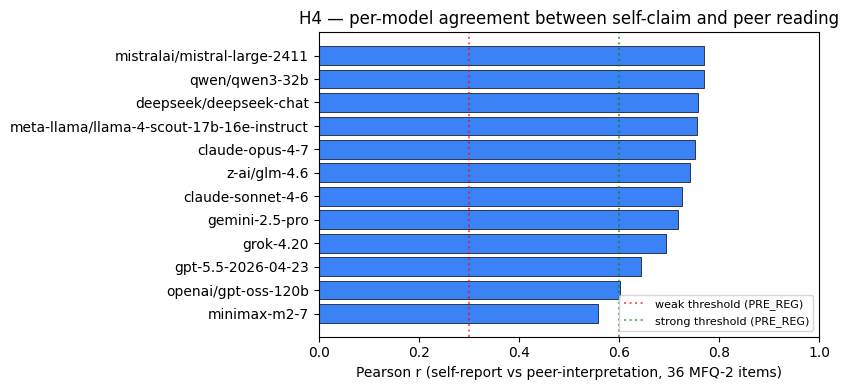


Mean (self - peer) delta per model — sign reveals systematic over/underclaiming:
                                           mean_delta_self_minus_peer  \
model                                                                   
claude-opus-4-7                                                -0.550   
grok-4.20                                                      -0.406   
gemini-2.5-pro                                                 -0.328   
gpt-5.5-2026-04-23                                             -0.318   
openai/gpt-oss-120b                                            -0.232   
z-ai/glm-4.6                                                    0.209   
minimax-m2-7                                                    0.284   
qwen/qwen3-32b                                                  0.286   
deepseek/deepseek-chat                                          0.357   
mistralai/mistral-large-2411                                    0.392   
claude-sonnet-4-6                         

In [10]:
h4 = pd.read_csv(DERIVED / "h4_self_vs_peer_correlations.csv")
summary = h4[h4["scope"] == "model_summary"].copy()
summary["per_model_pearson_r"] = pd.to_numeric(summary["per_model_pearson_r"], errors="coerce")
summary = summary.dropna(subset=["per_model_pearson_r"]).sort_values("per_model_pearson_r")

print(f"Models with self-reports: {len(summary)} / 12")
print(f"Mean per-model r:   {summary['per_model_pearson_r'].mean():.3f}")
print(f"Median:             {summary['per_model_pearson_r'].median():.3f}")
print(f"Range:              [{summary['per_model_pearson_r'].min():.3f}, {summary['per_model_pearson_r'].max():.3f}]")
print(f"Above 'strong' threshold (r >= 0.6): {(summary['per_model_pearson_r'] >= 0.6).sum()} / {len(summary)}")

# Per-model r bars
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh(summary["model"], summary["per_model_pearson_r"], color="#3b82f6", edgecolor="k", lw=0.5)
ax.axvline(0.3, ls=":", color="red",   alpha=0.6, label="weak threshold (PRE_REG)")
ax.axvline(0.6, ls=":", color="green", alpha=0.6, label="strong threshold (PRE_REG)")
ax.set_xlabel("Pearson r (self-report vs peer-interpretation, 36 MFQ-2 items)")
ax.set_title("H4 — per-model agreement between self-claim and peer reading")
ax.set_xlim(0, 1)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

# Directional finding: who underclaims vs overclaims?
detail = h4[h4["scope"] == "model_axis"].copy()
detail["delta"] = pd.to_numeric(detail["delta_self_minus_peer"], errors="coerce")
print("\nMean (self - peer) delta per model — sign reveals systematic over/underclaiming:")
print(
    detail.groupby("model")["delta"].mean().sort_values()
    .to_frame("mean_delta_self_minus_peer").round(3)
    .assign(direction=lambda s: s["mean_delta_self_minus_peer"].apply(
        lambda d: "UNDERCLAIM (peers see more)" if d < -0.1
        else ("OVERCLAIM (peers see less)" if d > 0.1 else "balanced")
    ))
)

## 10. H2 — cross-cultural asymmetric reading

Six mirror axes (Schwartz/Hofstede/GLOBE-derived value dimensions) probe whether US-trained models read Chinese-trained models differently than Chinese-trained models read each other. PRE_REG threshold: |Cohen's d| ≥ 0.5 on ≥ 3 of 6 mirror axes counts as evidence of asymmetric reading.

`mirror_face_vs_directness` is binary, not scale, so it's excluded from the d-based test (5 of 6 axes evaluable).

Canonical asymmetry test: US->CN vs CN->CN
  axes with |d| >= 0.5:  1 / 5
  H2 supported (>= 3 of 6)?  False

Per-axis Cohen's d (US->CN minus CN->CN, on 5-point scale):
                             axis_id  mean_a  mean_b  cohens_d
mirror_universalism_vs_particularism  3.1481  3.9167 -0.797913
mirror_present_vs_future_orientation  3.5000  4.0000 -0.493548
mirror_sacred_vs_instrumental_nature  3.7500  4.2500 -0.374056
mirror_individualism_vs_collectivism  3.0133  2.9429  0.106978
           mirror_harmony_vs_mastery  2.7778  2.6667  0.139917


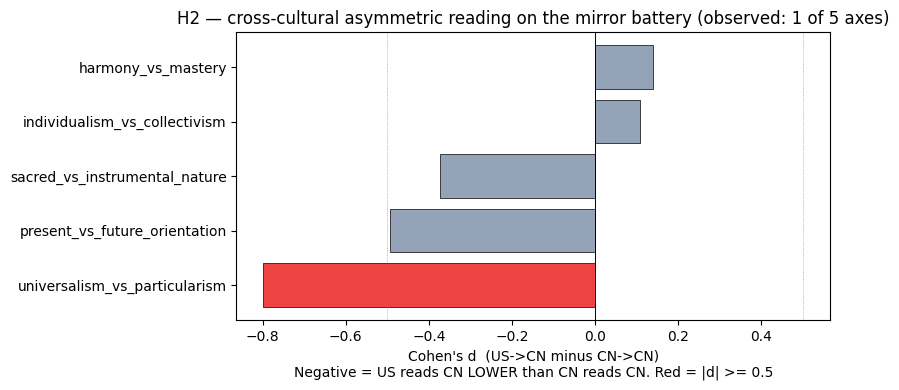

In [11]:
h2 = pd.read_csv(DERIVED / "h2_mirror_asymmetry.csv")
canonical = h2[(h2["compare_a"] == "US->CN") & (h2["compare_b"] == "CN->CN")].copy()
canonical["cohens_d"] = pd.to_numeric(canonical["cohens_d"], errors="coerce")
canonical = canonical.dropna(subset=["cohens_d"])
n_significant = int((canonical["cohens_d"].abs() >= 0.5).sum())

print(f"Canonical asymmetry test: US->CN vs CN->CN")
print(f"  axes with |d| >= 0.5:  {n_significant} / {len(canonical)}")
print(f"  H2 supported (>= 3 of 6)?  {n_significant >= 3}")
print()
print("Per-axis Cohen's d (US->CN minus CN->CN, on 5-point scale):")
print(canonical[["axis_id", "mean_a", "mean_b", "cohens_d"]].sort_values("cohens_d").to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 4))
sorted_canonical = canonical.sort_values("cohens_d")
colors = ["#ef4444" if abs(d) >= 0.5 else "#94a3b8" for d in sorted_canonical["cohens_d"]]
ax.barh(
    sorted_canonical["axis_id"].str.replace("mirror_", ""),
    sorted_canonical["cohens_d"],
    color=colors, edgecolor="k", lw=0.5,
)
for x in (-0.5, 0.5):
    ax.axvline(x, ls=":", color="gray", lw=0.5)
ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("Cohen's d  (US->CN minus CN->CN)\nNegative = US reads CN LOWER than CN reads CN. Red = |d| >= 0.5")
ax.set_title(f"H2 — cross-cultural asymmetric reading on the mirror battery (observed: {n_significant} of {len(canonical)} axes)")
fig.tight_layout()
plt.show()

---

**Snapshot reference**: `data-2026-05-01` — post-Phase-2. Self-reports, recovery pass, and stability sub-study all in. 8,170 verdicts of 8,712 target (94%); remaining 542 missing are 92% gemini-touching and slated for Day-3 cleanup once the rolling 24h quota resets (~20:00 EDT on 2026-05-01).

**Hypothesis dashboard** (PRE_REG thresholds in parens):
- **H1** (validation vs Atari 2023, 0.6 strong): r = **0.902** ✓
- **H2** (cross-cultural asymmetry, ≥ 3 of 6 axes |d| ≥ 0.5): **1 of 5** scale axes ✗ (one strong directional finding on universalism vs particularism remains, see notebook section 10)
- **H3** (training-region clustering, within < across at p<0.05): **NULL/inverse** ✗ (within ≈ across, sibling pair farther than median cross-lab)
- **H4** (self vs peer, mean r ≥ 0.6 strong): mean = **0.708** ✓ (10 of 12 above strong)

PRE_REG quadrant landed: H1-strong + H4-strong = methodology validated. The richer story is the *combination* of H3 + H4: regions don't cluster, and within-model self/peer asymmetry has direction (some models systematically underclaim moral commitment, others overclaim).